In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('cleaned_recipes.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157973 entries, 0 to 157972
Data columns (total 22 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   RecipeId                    157973 non-null  int64  
 1   Name                        157973 non-null  object 
 2   CookTime                    157973 non-null  object 
 3   PrepTime                    157973 non-null  object 
 4   TotalTime                   157973 non-null  object 
 5   Description                 157973 non-null  object 
 6   Images                      157973 non-null  object 
 7   RecipeCategory              157973 non-null  object 
 8   Keywords                    157973 non-null  object 
 9   RecipeIngredientQuantities  157973 non-null  object 
 10  RecipeIngredientParts       157973 non-null  object 
 11  Calories                    157973 non-null  float64
 12  FatContent                  157973 non-null  float64
 13  SaturatedFatCo

In [4]:
df.head()

,RecipeId,Name,CookTime,PrepTime,TotalTime,Description,Images,RecipeCategory,Keywords,RecipeIngredientQuantities,...,FatContent,SaturatedFatContent,CholesterolContent,SodiumContent,CarbohydrateContent,FiberContent,SugarContent,ProteinContent,RecipeServings,RecipeInstructions
0,1,Low-Fat Berry Blue Frozen Dessert,PT24H,PT45M,PT24H45M,Make and share this Low-Fat Berry Blue Frozen ...,"c(""https://img.sndimg.com/food/image/upload/w_...",Frozen Desserts,"c(""Dessert"", ""Low Protein"", ""Low Cholesterol"",...","c(""4"", ""1/4"", ""1"", ""1"")",...,2.5,1.3,8.0,29.8,37.1,3.6,30.2,3.2,4.0,"c(""Toss 2 cups berries with sugar."", ""Let stan..."
1,2,Biryani,PT25M,PT4H,PT4H25M,Make and share this Biryani recipe from Food.com.,"c(""https://img.sndimg.com/food/image/upload/w_...",Chicken Breast,"c(""Chicken Thigh & Leg"", ""Chicken"", ""Poultry"",...","c(""1"", ""4"", ""2"", ""2"", ""8"", ""1/4"", ""8"", ""1/2"", ...",...,58.8,16.6,372.8,368.4,84.4,9.0,20.4,63.4,6.0,"c(""Soak saffron in warm milk for 5 minutes and..."
2,3,Best Lemonade,PT5M,PT30M,PT35M,This is from one of my first Good House Keepi...,"c(""https://img.sndimg.com/food/image/upload/w_...",Beverages,"c(""Low Protein"", ""Low Cholesterol"", ""Healthy"",...","c(""1 1/2"", ""1"", NA, ""1 1/2"", NA, ""3/4"")",...,0.2,0.0,0.0,1.8,81.5,0.4,77.2,0.3,4.0,"c(""Into a 1 quart Jar with tight fitting lid, ..."
3,4,Carina's Tofu-Vegetable Kebabs,PT20M,PT24H,PT24H20M,This dish is best prepared a day in advance to...,"c(""https://img.sndimg.com/food/image/upload/w_...",Soy/Tofu,"c(""Beans"", ""Vegetable"", ""Low Cholesterol"", ""We...","c(""12"", ""1"", ""2"", ""1"", ""10"", ""1"", ""3"", ""2"", ""2...",...,24.0,3.8,0.0,1558.6,64.2,17.3,32.1,29.3,2.0,"c(""Drain the tofu, carefully squeezing out exc..."
4,5,Cabbage Soup,PT30M,PT20M,PT50M,Make and share this Cabbage Soup recipe from F...,"c(""https://img.sndimg.com/food/image/upload/w_...",Vegetable,"c(""Low Protein"", ""Vegan"", ""Low Cholesterol"", ""...","c(""46"", ""4"", ""1"", ""2"", ""1"")",...,0.4,0.1,0.0,959.3,25.1,4.8,17.7,4.3,4.0,"c(""Mix everything together and bring to a boil..."


In [5]:
# ── Imports & GPU setup ───────────────────────────────────────────────────────
import importlib, subprocess, sys, os, inspect, math, re, ast, csv
from io import StringIO
from typing import List

required_pkgs = ["torch", "transformers", "accelerate", "sentencepiece", "isodate", "scikit-learn", "joblib"]
missing = [p for p in required_pkgs
           if not importlib.util.find_spec("sklearn" if p == "scikit-learn" else p)]
if missing:
    print("Installing:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

import numpy as np
import torch
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, DataCollatorForSeq2Seq, T5ForConditionalGeneration,
    Trainer, TrainingArguments, TrainerCallback,
)
import isodate
import matplotlib.pyplot as plt
from IPython.display import clear_output

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

USE_CUDA = torch.cuda.is_available()
USE_BF16 = bool(USE_CUDA and torch.cuda.is_bf16_supported())
USE_FP16 = bool(USE_CUDA and not USE_BF16)
PIN_MEMORY = USE_CUDA

if USE_CUDA:
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision("high")
    gpu_name = torch.cuda.get_device_name(0)
    total_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
    print(f"CUDA enabled  : {gpu_name} ({total_gb:.1f} GB)")
    print(f"AMP mode      : bf16={USE_BF16}, fp16={USE_FP16}")
else:
    print("WARNING: CUDA not available — training will be very slow!")

Installing: ['torch', 'transformers', 'accelerate', 'sentencepiece', 'isodate']


ERROR: Operation cancelled by user


KeyboardInterrupt: 

In [6]:
# ── Preprocessing ─────────────────────────────────────────────────────────────
NUTRITION_COLS = [
    "Calories", "FatContent", "SaturatedFatContent", "CholesterolContent",
    "SodiumContent", "CarbohydrateContent", "FiberContent", "SugarContent", "ProteinContent",
]

UNIT_WORDS = {
    "tsp", "teaspoon", "teaspoons", "tbsp", "tablespoon", "tablespoons",
    "cup", "cups", "oz", "ounce", "ounces", "lb", "lbs", "pound", "pounds",
    "g", "gram", "grams", "kg", "ml", "l", "liter", "liters", "pinch", "dash",
    "clove", "cloves", "slice", "slices", "can", "cans", "package", "packages",
}

def parse_list_like(value) -> List[str]:
    if isinstance(value, list):
        return [str(x).strip() for x in value if str(x).strip()]
    if pd.isna(value): return []
    text = str(value).strip()
    if not text: return []
    if text.startswith("[") and text.endswith("]"):
        try:
            parsed = ast.literal_eval(text)
            return [str(x).strip() for x in parsed if str(x).strip()]
        except Exception: pass
    if text.startswith("c(") and text.endswith(")"):
        inner = text[2:-1].strip()
        reader = csv.reader(StringIO(inner), delimiter=",", quotechar='"', skipinitialspace=True)
        row = next(reader, [])
        return [t.strip().replace('""', '"') for t in row if t.strip() not in {"", "NA", "None", "nan"}]
    return [text]

def parse_iso_minutes(value) -> float:
    if pd.isna(value): return 0.0
    text = str(value).strip()
    if not text: return 0.0
    try:
        duration = isodate.parse_duration(text)
        if hasattr(duration, "total_seconds"):
            return float(duration.total_seconds() / 60.0)
    except Exception: pass
    m = re.match(r"P(?:(\d+)D)?(?:T(?:(\d+)H)?(?:(\d+)M)?)?", text)
    if not m: return 0.0
    return float(int(m.group(1) or 0) * 1440 + int(m.group(2) or 0) * 60 + int(m.group(3) or 0))

def normalize_ingredient(token: str) -> str:
    s = token.lower().strip()
    s = re.sub(r"\([^)]*\)", " ", s)
    s = re.sub(r"^\s*(?:\d+\s+\d+/\d+|\d+/\d+|\d+(?:\.\d+)?)\s*", "", s)
    s = re.sub(r"^\s*(?:x|about|approx\.?|approximately)\s+", "", s)
    parts = s.split()
    while parts and re.fullmatch(r"\d+(?:\.\d+)?", parts[0]): parts.pop(0)
    while parts and parts[0] in UNIT_WORDS: parts.pop(0)
    s = " ".join(parts)
    s = re.sub(r"[^a-zA-Z\s-]", " ", s)
    return re.sub(r"\s+", " ", s).strip(" -")

def build_input_prompt(ingredients: List[str], total_minutes: float) -> str:
    cleaned = list(dict.fromkeys([normalize_ingredient(x) for x in ingredients if normalize_ingredient(x)]))
    prompt = f"ingredients: {', '.join(cleaned[:40])}"
    if total_minutes > 0:
        prompt += f" | ready_in_min: {int(total_minutes)}"
    return prompt

def build_target_text(name: str, instructions: List[str]) -> str:
    steps = [s.strip() for s in instructions if s and s.strip()][:25]
    body = "\n".join(f"{i+1}. {s}" for i, s in enumerate(steps))
    title = str(name).strip() if pd.notna(name) else "Unknown Recipe"
    return f"name: {title}\nsteps:\n{body}"

df_work = df.copy()
df_work["_ingredient_list"] = df_work["RecipeIngredientParts"].apply(parse_list_like)
df_work["_instruction_list"] = df_work["RecipeInstructions"].apply(parse_list_like)
df_work["_total_minutes"]    = df_work["TotalTime"].apply(parse_iso_minutes)

# Fix servings
df_work["RecipeServings"] = pd.to_numeric(df_work["RecipeServings"], errors="coerce")
serving_median = df_work["RecipeServings"].dropna().median()
serving_median = serving_median if (not pd.isna(serving_median) and serving_median > 0) else 4.0
df_work["RecipeServings"] = df_work["RecipeServings"].fillna(serving_median).clip(lower=1.0)

# Per-serving nutrition
for col in NUTRITION_COLS:
    df_work[col] = pd.to_numeric(df_work[col], errors="coerce") / df_work["RecipeServings"]

# ── CHANGE 1: Clip extreme outliers before scaling ────────────────────────────
# This directly reduces RMSE for Calories and Sodium, which had the worst errors.
# Values above these caps are unrealistic for a single serving.
CLIP_CAPS = {
    "Calories":           1500.0,
    "SodiumContent":      3000.0,
    "CholesterolContent":  500.0,
    "FatContent":          150.0,
    "SaturatedFatContent":  60.0,
    "SugarContent":        200.0,
    "CarbohydrateContent": 300.0,
    "ProteinContent":      150.0,
    "FiberContent":         50.0,
}
for col, cap in CLIP_CAPS.items():
    before = (df_work[col] > cap).sum()
    df_work[col] = df_work[col].clip(upper=cap)
    if before > 0:
        print(f"Clipped {before:,} outliers in {col} (cap={cap})")

# Build text columns
df_work["input_text"]  = df_work.apply(lambda r: build_input_prompt(r["_ingredient_list"], r["_total_minutes"]), axis=1)
df_work["target_text"] = df_work.apply(lambda r: build_target_text(r["Name"], r["_instruction_list"]), axis=1)

df_work = df_work[df_work["input_text"].str.len() > 15]
df_work = df_work[df_work["target_text"].str.len() > 20]
df_work = df_work.dropna(subset=NUTRITION_COLS).reset_index(drop=True)

print(f"Prepared rows : {len(df_work):,}")
print(df_work[["input_text", "target_text"]].head(2))

Clipped 460 outliers in Calories (cap=1500.0)
Clipped 563 outliers in SodiumContent (cap=3000.0)
Clipped 227 outliers in CholesterolContent (cap=500.0)
Clipped 181 outliers in FatContent (cap=150.0)
Clipped 184 outliers in SaturatedFatContent (cap=60.0)
Clipped 194 outliers in SugarContent (cap=200.0)
Clipped 210 outliers in CarbohydrateContent (cap=300.0)
Clipped 56 outliers in ProteinContent (cap=150.0)
Clipped 36 outliers in FiberContent (cap=50.0)
Prepared rows : 157,973
                                          input_text  \
0  ingredients: blueberries, granulated sugar, va...   
1  ingredients: saffron, milk, hot green chili pe...   

                                         target_text  
0  name: Low-Fat Berry Blue Frozen Dessert\nsteps...  
1  name: Biryani\nsteps:\n1. Soak saffron in warm...  


In [7]:
# ── Split, scale targets, build datasets ──────────────────────────────────────
# MAX_ROWS = len(df_work)          # use all 157k rows
MAX_ROWS = 20000  # for quick testing; set to None or len(df_work) to use all data
df_model = df_work.sample(MAX_ROWS, random_state=SEED).reset_index(drop=True) if len(df_work) > MAX_ROWS else df_work.copy()

train_idx, val_idx = train_test_split(np.arange(len(df_model)), test_size=0.1, random_state=SEED)
train_df = df_model.iloc[train_idx].reset_index(drop=True)
val_df   = df_model.iloc[val_idx].reset_index(drop=True)

# Log-transform heavy-tailed columns before scaling
LOG_TARGET_COLS = {"Calories", "SodiumContent", "CholesterolContent"}

def _transform_target_frame(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame[NUTRITION_COLS].astype(np.float32).copy()
    for col in LOG_TARGET_COLS:
        out[col] = np.log1p(np.clip(out[col].to_numpy(dtype=np.float32), 0.0, None))
    return out

def inverse_targets(y_scaled: np.ndarray) -> np.ndarray:
    y_t = np.asarray(scaler.inverse_transform(y_scaled), dtype=np.float32).copy()
    for i, col in enumerate(NUTRITION_COLS):
        if col in LOG_TARGET_COLS:
            y_t[:, i] = np.expm1(y_t[:, i])
    return np.clip(y_t, 0.0, None)

scaler = StandardScaler()
train_targets = np.nan_to_num(scaler.fit_transform(_transform_target_frame(train_df).to_numpy(dtype=np.float32)).astype(np.float32))
val_targets   = np.nan_to_num(scaler.transform(_transform_target_frame(val_df).to_numpy(dtype=np.float32)).astype(np.float32))

# Save scaler immediately
CKPT_DIR       = "./recipe_multitask_ckpt"
MODEL_SAVE_DIR = "./recipe_model_final"
os.makedirs(CKPT_DIR, exist_ok=True)
joblib.dump(scaler, os.path.join(CKPT_DIR, "scaler.pkl"))

# Per-target loss weights (inverse std — makes the model care equally about all nutrients)
raw_std = _transform_target_frame(train_df).std(axis=0).to_numpy(dtype=np.float32) + 1e-6
target_weights_np = (1.0 / raw_std) / (1.0 / raw_std).mean()
TARGET_WEIGHTS_T  = torch.tensor(target_weights_np.astype(np.float32))

# ── CHANGE 2: Switch from flan-t5-small to flan-t5-base ──────────────────────
# base has 250M params vs small's 80M — significantly better recipe generation
# fits comfortably in 8GB VRAM with bf16
MODEL_NAME     = "google/flan-t5-base"
MAX_INPUT_LEN  = 128
MAX_TARGET_LEN = 300   # slightly longer to avoid truncating recipe steps

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class RecipeDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, y_scaled: np.ndarray):
        self.frame = frame
        self.y = y_scaled
    def __len__(self): return len(self.frame)
    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        model_in  = tokenizer(row["input_text"],  truncation=True, max_length=MAX_INPUT_LEN)
        model_out = tokenizer(text_target=row["target_text"], truncation=True, max_length=MAX_TARGET_LEN)
        return {
            "input_ids":      model_in["input_ids"],
            "attention_mask": model_in["attention_mask"],
            "labels":         model_out["input_ids"],
            "reg_targets":    torch.tensor(self.y[idx], dtype=torch.float32),
        }

data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=MODEL_NAME, padding=True)

def multitask_collate(features):
    reg_targets = torch.stack([f["reg_targets"] for f in features])
    core  = [{k: v for k, v in f.items() if k != "reg_targets"} for f in features]
    batch = data_collator(core)
    batch["labels"][batch["labels"] == tokenizer.pad_token_id] = -100
    if not torch.isfinite(reg_targets).all():
        raise ValueError("Non-finite values in reg_targets")
    if (batch["labels"] != -100).sum().item() == 0:
        raise ValueError("All labels are -100")
    batch["reg_targets"] = reg_targets
    return batch

train_ds = RecipeDataset(train_df, train_targets)
val_ds   = RecipeDataset(val_df,   val_targets)

print(f"Model         : {MODEL_NAME}")
print(f"Train / Val   : {len(train_ds):,} / {len(val_ds):,}")
print(f"Target weights: {dict(zip(NUTRITION_COLS, target_weights_np.round(3)))}")

NameError: name 'SEED' is not defined

In [19]:
# ── Model definition ──────────────────────────────────────────────────────────
class MultiTaskFlanT5(nn.Module):
    def __init__(self, model_name: str, num_targets: int, reg_weight: float = 0.5,
                 target_weights: torch.Tensor = None):
        super().__init__()
        self.backbone = T5ForConditionalGeneration.from_pretrained(model_name)
        self.backbone.config.tie_word_embeddings = False
        hidden = self.backbone.config.d_model

        # ── CHANGE 3: Deeper regression head ─────────────────────────────────
        # Added an extra hidden layer (hidden→256→128→targets) vs the old (hidden→hidden→targets)
        # More capacity = better nutrition prediction without hurting recipe generation
        self.reg_head = nn.Sequential(
            nn.Linear(hidden, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, num_targets),
        )
        self.reg_weight = reg_weight
        self.register_buffer("target_weights",
            (target_weights if target_weights is not None else torch.ones(num_targets)).float())

    def gradient_checkpointing_enable(self, gradient_checkpointing_kwargs=None):
        if hasattr(self.backbone, "gradient_checkpointing_enable"):
            if gradient_checkpointing_kwargs:
                self.backbone.gradient_checkpointing_enable(gradient_checkpointing_kwargs=gradient_checkpointing_kwargs)
            else:
                self.backbone.gradient_checkpointing_enable()

    def gradient_checkpointing_disable(self):
        if hasattr(self.backbone, "gradient_checkpointing_disable"):
            self.backbone.gradient_checkpointing_disable()

    def forward(self, input_ids=None, attention_mask=None, labels=None, reg_targets=None, **kwargs):
        out = self.backbone(input_ids=input_ids, attention_mask=attention_mask,
                            labels=labels, return_dict=True)
        enc_hidden = out.encoder_last_hidden_state
        mask   = attention_mask.unsqueeze(-1).float()
        pooled = (enc_hidden * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-6)
        reg_pred = self.reg_head(pooled)

        ce_loss  = out.loss if out.loss is not None else torch.tensor(0.0, device=input_ids.device)
        reg_loss = torch.tensor(0.0, device=input_ids.device)
        if reg_targets is not None:
            loss_val = nn.SmoothL1Loss(reduction="none")(reg_pred, reg_targets)
            w = self.target_weights.view(1, -1).to(loss_val.device)
            reg_loss = (loss_val * w).mean()

        total_loss = ce_loss + self.reg_weight * reg_loss
        if not torch.isfinite(total_loss):
            raise RuntimeError(f"Non-finite loss: total={total_loss.item():.4f} ce={ce_loss.item():.4f} reg={reg_loss.item():.4f}")
        return {"loss": total_loss, "logits": out.logits, "regression_logits": reg_pred,
                "ce_loss": ce_loss.detach(), "reg_loss": reg_loss.detach()}

    @torch.no_grad()
    def generate_text(self, input_ids, attention_mask, **kwargs):
        return self.backbone.generate(input_ids=input_ids, attention_mask=attention_mask, **kwargs)

In [20]:
# ── Sanity check (forward pass before full training) ──────────────────────────
device = torch.device("cuda" if USE_CUDA else "cpu")
amp_dtype = torch.bfloat16 if USE_BF16 else torch.float16

model = MultiTaskFlanT5(MODEL_NAME, num_targets=len(NUTRITION_COLS),
                        reg_weight=0.5, target_weights=TARGET_WEIGHTS_T)
model.to(device)

batch = multitask_collate([train_ds[i] for i in range(min(4, len(train_ds)))])
batch = {k: v.to(device) for k, v in batch.items()}

with torch.no_grad():
    if USE_CUDA:
        with torch.autocast(device_type="cuda", dtype=amp_dtype):
            out = model(**batch)
    else:
        out = model(**batch)

print(f"Sanity loss : {float(out['loss']):.4f}")
print(f"CE loss     : {float(out['ce_loss']):.4f}")
print(f"REG loss    : {float(out['reg_loss']):.4f}")
print("Sanity check passed — model is wired correctly.")

Loading weights: 100%|██████████| 282/282 [00:00<00:00, 3527.14it/s]
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Sanity loss : 3.1110
CE loss     : 2.9514
REG loss    : 0.3192
Sanity check passed — model is wired correctly.


In [21]:
# ── Callbacks: live loss plot + best model saver ───────────────────────────────
class LivePlotCallback(TrainerCallback):
    def __init__(self):
        self.steps, self.train_losses, self.eval_losses = [], [], []
        self.eval_steps = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "loss" in logs:
            self.steps.append(state.global_step)
            self.train_losses.append(logs["loss"])
            clear_output(wait=True)
            plt.figure(figsize=(10, 4))
            plt.plot(self.steps, self.train_losses, label="Train loss", color="purple")
            if self.eval_steps:
                plt.plot(self.eval_steps, self.eval_losses, label="Val loss", color="orange", marker="o")
            plt.title(f"Training — step {state.global_step} / epoch {state.epoch:.2f}")
            plt.xlabel("Step"); plt.ylabel("Loss")
            plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics and "eval_loss" in metrics:
            self.eval_steps.append(state.global_step)
            self.eval_losses.append(metrics["eval_loss"])

class BestModelSaver(TrainerCallback):
    """Saves the full model state whenever eval_loss improves."""
    def __init__(self, save_dir: str):
        self.save_dir = save_dir
        self.best = float("inf")
        os.makedirs(save_dir, exist_ok=True)

    def on_evaluate(self, args, state, control, metrics=None, model=None, **kwargs):
        if not metrics or "eval_loss" not in metrics or model is None: return
        current = float(metrics["eval_loss"])
        if current < self.best:
            self.best = current
            path = os.path.join(self.save_dir, "best_model.pt")
            torch.save({
                "model_state_dict": model.state_dict(),
                "reg_weight": model.reg_weight,
                "target_weights": TARGET_WEIGHTS_T.cpu().numpy(),
                "scaler_mean": scaler.mean_,
                "scaler_scale": scaler.scale_,
                "nutrition_cols": NUTRITION_COLS,
                "log_target_cols": list(LOG_TARGET_COLS),
                "step": state.global_step,
                "best_eval_loss": self.best,
            }, path)
            print(f"  [BestModelSaver] step={state.global_step} eval_loss={self.best:.4f} → saved to {path}")

plot_callback      = LivePlotCallback()
best_model_saver   = BestModelSaver(save_dir=CKPT_DIR)
print("Callbacks ready.")

Callbacks ready.


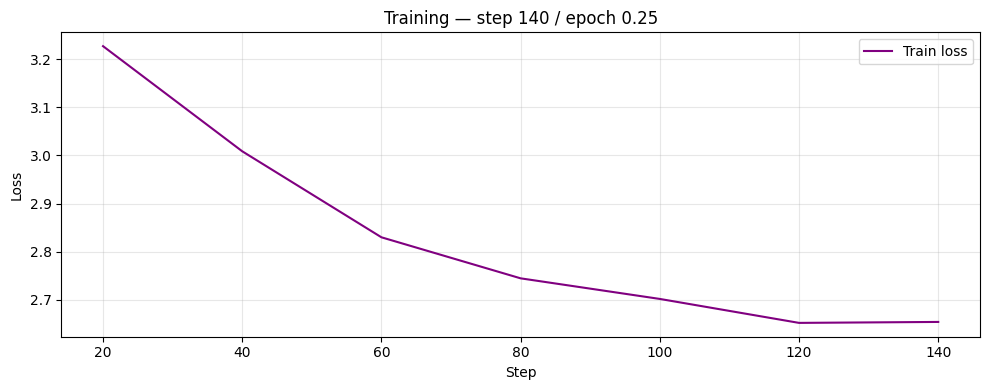

In [ ]:
# ── Training ──────────────────────────────────────────────────────────────────
# ── CHANGE 4: 3 epochs instead of 1 ─────────────────────────────────────────
# 1 epoch gave train_loss ~3.0 and R²≈0. 3 epochs lets the model actually learn
# ingredient→recipe mappings. Expected time on RTX 4060: ~6-8 hours total.
# ── CHANGE 5: eval_strategy="epoch" so we track val loss each epoch ──────────
# ── CHANGE 6: lower learning rate (2e-5 → 1e-4 warmup then cosine decay) ─────

REG_WEIGHT = 0.5   # balanced CE + regression loss

model = MultiTaskFlanT5(MODEL_NAME, num_targets=len(NUTRITION_COLS),
                        reg_weight=REG_WEIGHT, target_weights=TARGET_WEIGHTS_T)
model.to(device)

supports_gc = hasattr(model, "gradient_checkpointing_enable")

args_dict = {
    "output_dir":                    CKPT_DIR,
    "num_train_epochs":              3,          # CHANGE: was 1
    "learning_rate":                 2e-4,       # slightly higher for faster convergence on base
    "lr_scheduler_type":             "cosine",
    "warmup_steps":                  200,
    "per_device_train_batch_size":   32,         # safe for 8GB VRAM with flan-t5-base + bf16
    "per_device_eval_batch_size":    16,
    "gradient_accumulation_steps":   1,          # effective batch = 32
    "weight_decay":                  0.01,
    "eval_strategy":                 "epoch",    # CHANGE: was "no" — now we see val loss per epoch
    "save_strategy":                 "no",       # BestModelSaver handles saving via .pt file
    "logging_steps":                 20,
    "report_to":                     "none",
    "fp16":                          False,
    "bf16":                          USE_BF16,
    "max_grad_norm":                 1.0,
    "remove_unused_columns":         False,
    "load_best_model_at_end":        False,
    "dataloader_num_workers":        0,          # 0 = no multiprocessing (required on Windows)
    "dataloader_pin_memory":         PIN_MEMORY,
    "eval_accumulation_steps":       4,
    "gradient_checkpointing":        supports_gc,
    "group_by_length":               False,       # groups similar-length sequences → faster training
}

supported       = set(inspect.signature(TrainingArguments.__init__).parameters.keys())
filtered_args   = {k: v for k, v in args_dict.items() if k in supported}
dropped         = sorted(set(args_dict) - set(filtered_args))
if dropped: print("Dropped unsupported args:", dropped)

training_args = TrainingArguments(**filtered_args)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=multitask_collate,
    callbacks=[plot_callback, best_model_saver],
)

print("Starting training...")
print(f"  Model      : {MODEL_NAME}")
print(f"  Epochs     : 3")
print(f"  Train size : {len(train_ds):,}")
print(f"  Batch size : {args_dict['per_device_train_batch_size']} × {args_dict['gradient_accumulation_steps']} accum = {args_dict['per_device_train_batch_size']*args_dict['gradient_accumulation_steps']} effective")
steps_per_epoch = math.ceil(len(train_ds) / (args_dict["per_device_train_batch_size"] * args_dict["gradient_accumulation_steps"]))
print(f"  Steps/epoch: ~{steps_per_epoch:,}  |  Total: ~{steps_per_epoch*3:,}")

train_result = trainer.train()
print("\nTraining complete!")
print(train_result.metrics)

In [ ]:
# ── Save final model ──────────────────────────────────────────────────────────
# Run once after training. After this, use cell below to load — no retraining needed.
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

# Use trainer.save_model to avoid the shared-tensor safetensors error
trainer.save_model(MODEL_SAVE_DIR)
tokenizer.save_pretrained(MODEL_SAVE_DIR)
torch.save(model.reg_head.state_dict(), os.path.join(MODEL_SAVE_DIR, "reg_head.pt"))
joblib.dump(scaler, os.path.join(MODEL_SAVE_DIR, "scaler.pkl"))
np.save(os.path.join(MODEL_SAVE_DIR, "target_weights.npy"), target_weights_np)
np.save(os.path.join(MODEL_SAVE_DIR, "log_target_cols.npy"), np.array(list(LOG_TARGET_COLS)))

print(f"Saved to: {MODEL_SAVE_DIR}/")
print(f"Contents: {os.listdir(MODEL_SAVE_DIR)}")

In [ ]:
# ── Load saved model (run this in future sessions instead of retraining) ───────
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained(MODEL_SAVE_DIR)
scaler    = joblib.load(os.path.join(MODEL_SAVE_DIR, "scaler.pkl"))
target_weights_np = np.load(os.path.join(MODEL_SAVE_DIR, "target_weights.npy"))
TARGET_WEIGHTS_T  = torch.tensor(target_weights_np)
LOG_TARGET_COLS   = set(np.load(os.path.join(MODEL_SAVE_DIR, "log_target_cols.npy"), allow_pickle=True).tolist())

model = MultiTaskFlanT5(MODEL_SAVE_DIR, num_targets=len(NUTRITION_COLS), target_weights=TARGET_WEIGHTS_T)
model.reg_head.load_state_dict(torch.load(os.path.join(MODEL_SAVE_DIR, "reg_head.pt"), map_location=device))
model.to(device)
model.eval()
print("Model loaded from disk and ready for inference.")

In [ ]:
# ── Recipe quality scorer & reranker (unchanged from your original) ────────────
ACTION_VERBS = {
    "add", "mix", "stir", "heat", "cook", "bake", "boil", "simmer", "saute", "fry",
    "chop", "slice", "season", "serve", "preheat", "whisk", "knead", "rest", "marinate",
    "drain", "rinse", "combine", "blend", "grill", "roast", "fold", "pour", "place",
}

def _extract_input_ingredients_from_prompt(input_text: str):
    head  = input_text.split("|", 1)[0].replace("ingredients:", "").strip()
    return [normalize_ingredient(p.strip()) for p in head.split(",") if normalize_ingredient(p.strip())]

def parse_generated_recipe_text(text: str):
    text  = re.sub(r"\s+", " ", text).strip()
    if not text: return "", []
    title = ""
    m = re.search(r"name\s*:\s*(.*?)(?=\s+steps\s*:|$)", text, flags=re.IGNORECASE)
    if m: title = m.group(1).strip()
    body  = re.sub(r"^.*?steps\s*:\s*", "", text, flags=re.IGNORECASE)
    parts = re.split(r"\s(?=\d+[\).]\s)", body)
    steps = [re.sub(r"^\d+[\).]\s+", "", p.strip()) for p in parts if re.match(r"^\d+[\).]\s+", p.strip())]
    if not steps:
        lines = [ln.strip() for ln in text.splitlines() if ln.strip()]
        steps = [re.sub(r"^\d+[\).]\s+", "", ln) for ln in lines if re.match(r"^\d+[\).]\s+", ln)]
        if not steps and len(lines) >= 3: steps = lines[:10]
    return title or "Generated Recipe", steps

def score_recipe_validity(generated_text: str, input_text: str):
    title, steps = parse_generated_recipe_text(generated_text)
    src_ings = set(_extract_input_ingredients_from_prompt(input_text))
    penalties, score = [], 100.0
    if len(title.strip()) < 3: score -= 10; penalties.append("missing_title")
    if len(steps) < 3: score -= 35; penalties.append("too_few_steps")
    if steps:
        short = sum(1 for s in steps if len(s.split()) < 4)
        if short > 0: score -= min(20, short * 5); penalties.append("very_short_steps")
        first_words  = [s.split()[0].lower() for s in steps if s.split()]
        verb_ratio   = sum(1 for w in first_words if w in ACTION_VERBS) / max(1, len(steps))
        if verb_ratio < 0.3: score -= 15; penalties.append("low_actionability")
        uniq_ratio   = len(set(s.lower() for s in steps)) / max(1, len(steps))
        if uniq_ratio < 0.8: score -= 15; penalties.append("repetitive_steps")
        full_text = " ".join(steps).lower()
        if re.search(r"\b([a-z]+(?:\s+[a-z]+){0,2})\s+and\s+\1\b", full_text):
            score -= 20; penalties.append("duplicated_phrase")
        if src_ings:
            repeated = sum(1 for ing in src_ings
                           for t in [tok for tok in ing.split() if len(tok) > 2]
                           if full_text.count(t) >= 4)
            if repeated > 0: score -= min(20, repeated * 6); penalties.append("over_repeated_ingredients")
        if src_ings:
            covered  = sum(1 for ing in src_ings
                           if any(t in full_text for t in [tok for tok in ing.split() if len(tok) > 2]))
            coverage = covered / max(1, len(src_ings))
            if coverage < 0.35: score -= 25; penalties.append("low_ingredient_alignment")
        else:
            coverage = float("nan")
    else:
        coverage = float("nan")
    return {"title": title, "steps": steps,
            "score": float(max(0.0, min(100.0, score))),
            "ingredient_coverage": float(coverage) if coverage == coverage else float("nan"),
            "penalties": penalties}

@torch.no_grad()
def generate_best_recipe(input_text: str, num_candidates: int = 5):
    device = next(model.parameters()).device
    enc = tokenizer(input_text, return_tensors="pt", truncation=True, max_length=MAX_INPUT_LEN)
    enc = {k: v.to(device) for k, v in enc.items()}
    gen_ids = model.generate_text(
        enc["input_ids"], enc["attention_mask"],
        max_length=MAX_TARGET_LEN,
        num_beams=max(6, num_candidates),
        num_return_sequences=num_candidates,
        do_sample=False,
        no_repeat_ngram_size=3,
        repetition_penalty=1.2,    # slightly stronger than before to reduce repetition
        length_penalty=0.95,
        early_stopping=True,
    )
    texts  = tokenizer.batch_decode(gen_ids, skip_special_tokens=True)
    scored = sorted([{"text": t, **score_recipe_validity(t, input_text)} for t in texts],
                    key=lambda x: x["score"], reverse=True)
    return scored[0], scored

print("Scoring utilities ready.")

In [ ]:
# ── Inference ─────────────────────────────────────────────────────────────────
def predict(ingredient_string: str, servings: float = 4.0, total_minutes: float = 0.0,
            num_candidates: int = 5, blend_alpha: float = 0.2):
    """
    ingredient_string : comma-separated ingredients, e.g. "chicken, garlic, lemon"
    blend_alpha       : weight of T5 regression head in blended nutrition (0=all Ridge, 1=all T5)
    """
    raw_ings   = [x.strip() for x in ingredient_string.split(",")]
    input_text = build_input_prompt(raw_ings, total_minutes)
    device     = next(model.parameters()).device
    amp_dtype  = torch.bfloat16 if USE_BF16 else torch.float16

    model.eval()
    best_recipe, all_candidates = generate_best_recipe(input_text, num_candidates=num_candidates)

    enc = tokenizer(input_text, return_tensors="pt", truncation=True, max_length=MAX_INPUT_LEN)
    enc = {k: v.to(device) for k, v in enc.items()}

    with torch.no_grad():
        ctx = torch.autocast(device_type="cuda", dtype=amp_dtype) if USE_CUDA else torch.no_grad()
        with ctx:
            enc_h  = model.backbone.encoder(input_ids=enc["input_ids"],
                                            attention_mask=enc["attention_mask"],
                                            return_dict=True).last_hidden_state
            mask   = enc["attention_mask"].unsqueeze(-1).float()
            pooled = (enc_h * mask).sum(1) / mask.sum(1).clamp(min=1.0)
            pred_scaled_mt = model.reg_head(pooled).float().cpu().numpy()

    pred_nutrition_mt = inverse_targets(pred_scaled_mt)[0]

    # Blend with Ridge regressor if available
    regressor_ready = all(n in globals() for n in ["tfidf", "xnum_scaler", "nutrition_model", "sparse"])
    if regressor_ready:
        from scipy import sparse as sp
        x_text = tfidf.transform([input_text])
        x_num  = xnum_scaler.transform(np.array([[servings, total_minutes]], dtype=np.float32))
        x_all  = sp.hstack([x_text, sp.csr_matrix(x_num)], format="csr")
        pred_reg  = np.clip(nutrition_model.predict(x_all).astype(np.float32)[0], 0.0, None)
        pred_nutrition = blend_alpha * pred_nutrition_mt + (1.0 - blend_alpha) * pred_reg
        mode = "blended"
    else:
        pred_nutrition = pred_nutrition_mt
        mode = "T5 multitask only"

    print("=" * 65)
    print(f"INPUT  : {input_text}")
    print("=" * 65)
    print(f"RECIPE (validity={best_recipe['score']:.0f}/100):")
    print(best_recipe["text"])
    print(f"\nNUTRITION per serving [{mode}]:")
    for col, val in zip(NUTRITION_COLS, pred_nutrition):
        print(f"  {col:<25}: {val:.1f}")
    if best_recipe["penalties"]:
        print(f"\nPenalties : {best_recipe['penalties']}")
    print("=" * 65)
    return best_recipe, pred_nutrition

# Example
predict("chicken breast, garlic, lemon, olive oil, rosemary, salt, pepper")

In [ ]:
# ── Regression metrics on full validation set ─────────────────────────────────
device = torch.device("cuda" if USE_CUDA else "cpu")
model.to(device)
model.eval()
amp_dtype = torch.bfloat16 if USE_BF16 else torch.float16

val_loader = DataLoader(val_ds, batch_size=64, shuffle=False,
                        collate_fn=multitask_collate, num_workers=0, pin_memory=PIN_MEMORY)

pred_scaled_all, true_scaled_all = [], []
with torch.no_grad():
    for batch in val_loader:
        ids  = batch["input_ids"].to(device, non_blocking=True)
        attn = batch["attention_mask"].to(device, non_blocking=True)
        regs = batch["reg_targets"].to(device, non_blocking=True)
        ctx  = torch.autocast(device_type="cuda", dtype=amp_dtype) if USE_CUDA else torch.no_grad()
        with ctx:
            enc_h  = model.backbone.encoder(input_ids=ids, attention_mask=attn, return_dict=True).last_hidden_state
            mask   = attn.unsqueeze(-1).float()
            pooled = (enc_h * mask).sum(1) / mask.sum(1).clamp(min=1e-6)
            preds  = model.reg_head(pooled)
        pred_scaled_all.append(preds.detach().float().cpu().numpy())
        true_scaled_all.append(regs.detach().float().cpu().numpy())

pred_unscaled = inverse_targets(np.concatenate(pred_scaled_all, axis=0))
true_unscaled = inverse_targets(np.concatenate(true_scaled_all, axis=0))

rows, eps = [], 1e-6
for i, col in enumerate(NUTRITION_COLS):
    err   = pred_unscaled[:, i] - true_unscaled[:, i]
    mae   = float(np.mean(np.abs(err)))
    rmse  = float(np.sqrt(np.mean(err ** 2)))
    denom = np.abs(true_unscaled[:, i])
    valid = denom > 1.0
    mape  = float(np.mean(np.abs(err[valid]) / denom[valid]) * 100.0) if np.any(valid) else float("nan")
    ss_res = float(np.sum(err ** 2))
    ss_tot = float(np.sum((true_unscaled[:, i] - np.mean(true_unscaled[:, i])) ** 2) + eps)
    r2    = 1.0 - ss_res / ss_tot
    rows.append({"nutrient": col, "MAE": mae, "RMSE": rmse, "MAPE_%": mape, "R2": r2})

metrics_df = pd.DataFrame(rows)
display(metrics_df.sort_values("MAE").round(3))
print(f"Overall MAE : {float(np.mean(np.abs(pred_unscaled - true_unscaled))):.4f}")
print(f"Overall RMSE: {float(np.sqrt(np.mean((pred_unscaled - true_unscaled)**2))):.4f}")

In [ ]:
# ── Ridge regressor baseline (for blending) ───────────────────────────────────
from scipy import sparse
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor

num_cols    = ["RecipeServings", "_total_minutes"]
tfidf       = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=50000)
X_tr_tfidf  = tfidf.fit_transform(train_df["input_text"].astype(str))
X_val_tfidf = tfidf.transform(val_df["input_text"].astype(str))

xnum_scaler = StandardScaler()
X_tr_num    = xnum_scaler.fit_transform(train_df[num_cols].to_numpy(dtype=np.float32))
X_val_num   = xnum_scaler.transform(val_df[num_cols].to_numpy(dtype=np.float32))

X_train_r   = sparse.hstack([X_tr_tfidf,  sparse.csr_matrix(X_tr_num)],  format="csr")
X_val_r     = sparse.hstack([X_val_tfidf, sparse.csr_matrix(X_val_num)], format="csr")
y_train_r   = train_df[NUTRITION_COLS].to_numpy(dtype=np.float32)
y_val_r     = val_df[NUTRITION_COLS].to_numpy(dtype=np.float32)

nutrition_model = MultiOutputRegressor(Ridge(alpha=3.0))
nutrition_model.fit(X_train_r, y_train_r)
y_pred_r = np.clip(nutrition_model.predict(X_val_r).astype(np.float32), 0.0, None)

rows = [{"nutrient": col,
         "MAE":  float(np.mean(np.abs(y_pred_r[:, i] - y_val_r[:, i]))),
         "RMSE": float(np.sqrt(np.mean((y_pred_r[:, i] - y_val_r[:, i])**2)))}
        for i, col in enumerate(NUTRITION_COLS)]
display(pd.DataFrame(rows).sort_values("MAE").round(3))
print("Ridge MAE :", round(float(np.mean(np.abs(y_pred_r - y_val_r))), 4))
print("Ridge RMSE:", round(float(np.sqrt(np.mean((y_pred_r - y_val_r)**2))), 4))

In [ ]:
# ── GPU stress test ───────────────────────────────────────────────────────────
# import time
# if torch.cuda.is_available():
#     d = torch.device("cuda")
#     print(f"GPU: {torch.cuda.get_device_name(0)}")
#     x, y = torch.randn(5000, 5000).to(d), torch.randn(5000, 5000).to(d)
#     t = time.time()
#     torch.matmul(x, y); torch.cuda.synchronize()
#     print(f"5000x5000 matmul: {time.time()-t:.4f}s")
# else:
#     print("GPU not found")